# SpendWise - Personal Finance & Spending Analysis

**Dataset:** Personal Finance Transactions (2018-2020)  
**Source:** [Kaggle - Personal Finance](https://www.kaggle.com/datasets/bukolafatunde/personal-finance)  
**Goal:** Analyse spending behaviour, category breakdowns, monthly trends, income vs expenses, and budget performance.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

matplotlib.rcParams['font.family']        = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['font.size'] = 12

OUT = 'outputs'
print('Libraries loaded!')

Libraries loaded!


## 2. Load Data

In [2]:
df  = pd.read_csv('data/personal_transactions.csv')
bud = pd.read_csv('data/Budget.csv')

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M')
df['MonthName'] = df['Date'].dt.strftime('%b %Y')

print(f'Transactions : {df.shape[0]:,}')
print(f'Period       : {df.Date.min().date()} to {df.Date.max().date()}')
print(f'Categories   : {df.Category.nunique()}')
df.head()

Transactions : 806
Period       : 2018-01-01 to 2019-09-30
Categories   : 22


,Date,Description,Amount,Transaction Type,Category,Account Name,Year,Month,MonthName
0,2018-01-01,Amazon,11.11,debit,Shopping,Platinum Card,2018,2018-01,Jan 2018
1,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,Checking,2018,2018-01,Jan 2018
2,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,Silver Card,2018,2018-01,Jan 2018
3,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,Platinum Card,2018,2018-01,Jan 2018
4,2018-01-04,Netflix,11.76,debit,Movies & DVDs,Platinum Card,2018,2018-01,Jan 2018


## 3. Data Overview

In [3]:
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.sum() > 0 else 'None')
print()
print('Transaction Types:')
print(df['Transaction Type'].value_counts())

Missing values:
None

Transaction Types:
Transaction Type
debit     688
credit    118
Name: count, dtype: int64


## 4. Income vs Expenses Overview

    SPENDWISE - FINANCIAL SUMMARY
  Total Income   : $124,269.76
  Total Expenses : $ 96,083.78
  Net Savings    : $ 28,185.98
  Savings Rate   :      22.7%


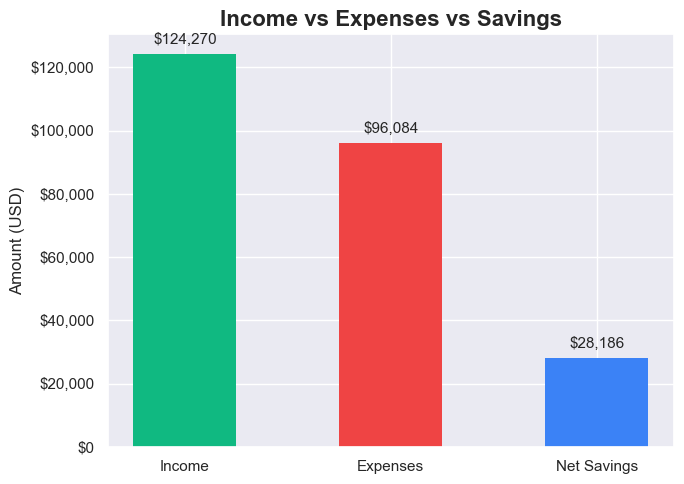

In [4]:
income   = df[df['Transaction Type'] == 'credit']['Amount'].sum()
expenses = df[df['Transaction Type'] == 'debit']['Amount'].sum()
savings  = income - expenses

print('=' * 40)
print('    SPENDWISE - FINANCIAL SUMMARY')
print('=' * 40)
print(f'  Total Income   : ${income:>10,.2f}')
print(f'  Total Expenses : ${expenses:>10,.2f}')
print(f'  Net Savings    : ${savings:>10,.2f}')
print(f'  Savings Rate   : {savings/income*100:>9.1f}%')
print('=' * 40)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Income', 'Expenses', 'Net Savings'],
              [income, expenses, savings],
              color=['#10b981', '#ef4444', '#3b82f6'], edgecolor='none', width=0.5)
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=11)
ax.set_title('Income vs Expenses vs Savings', fontsize=16, fontweight='bold')
ax.set_ylabel('Amount (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{OUT}/income_vs_expenses.png', dpi=150)
plt.show()

## 5. Monthly Spending Trend

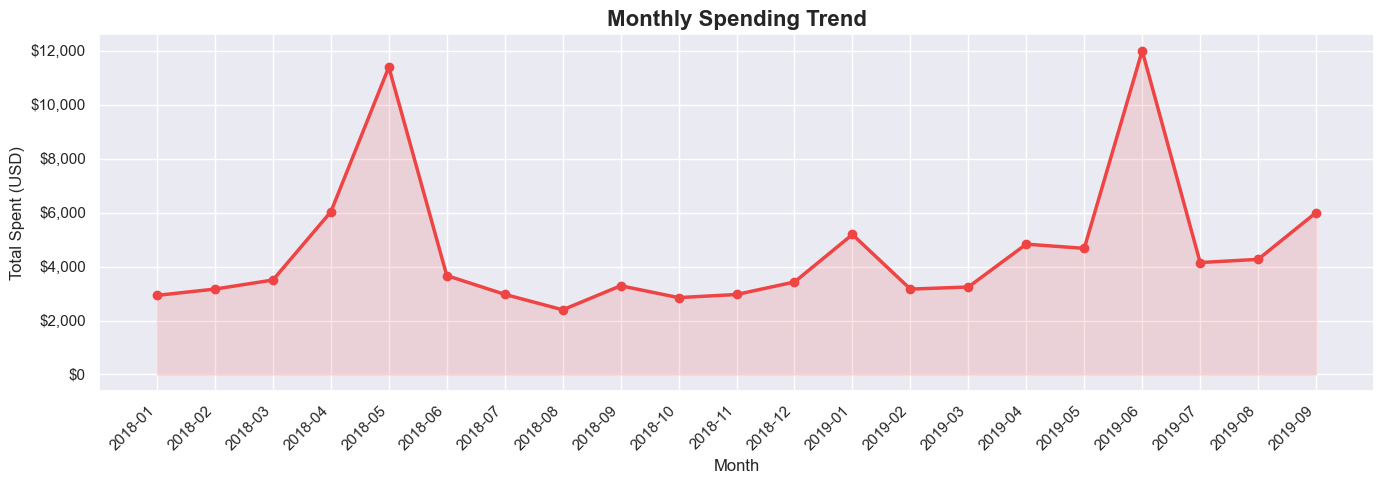

In [5]:
monthly = (
    df[df['Transaction Type'] == 'debit']
    .groupby('Month')['Amount'].sum()
    .reset_index()
)
monthly['Month'] = monthly['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], monthly['Amount'], marker='o', linewidth=2.5, color='#ef4444')
ax.fill_between(monthly['Month'], monthly['Amount'], alpha=0.15, color='#ef4444')
ax.set_title('Monthly Spending Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Spent (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{OUT}/monthly_spending.png', dpi=150)
plt.show()

## 6. Top Spending Categories

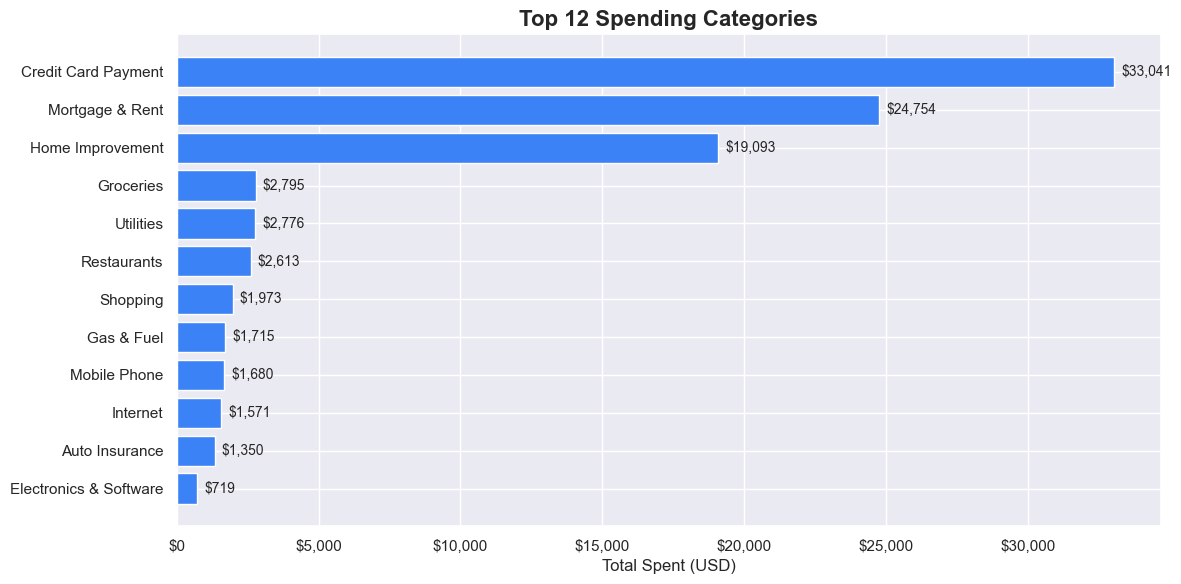

In [6]:
top_cat = (
    df[df['Transaction Type'] == 'debit']
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cat['Category'], top_cat['Amount'], color='#3b82f6')
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=10)
ax.set_title('Top 12 Spending Categories', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Spent (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUT}/top_categories.png', dpi=150)
plt.show()

## 7. Spending Distribution by Category (Pie Chart)

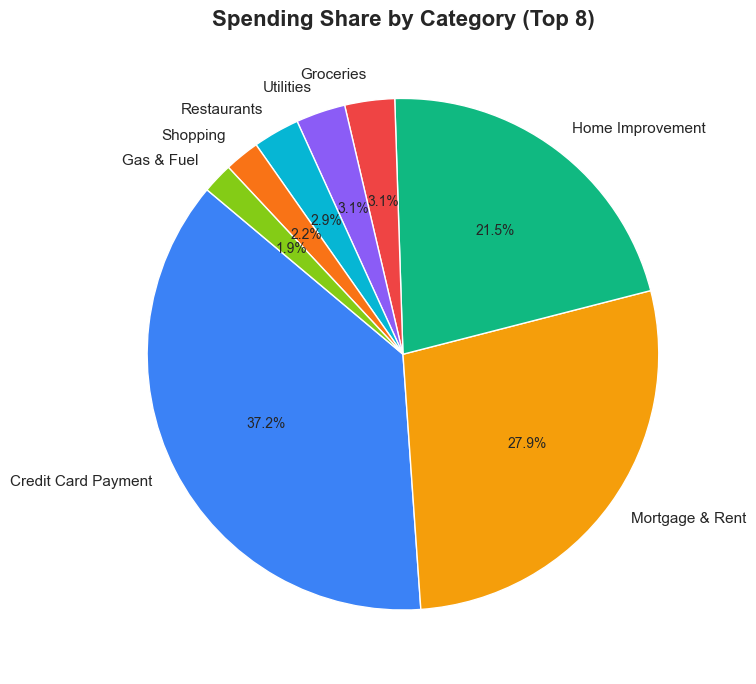

In [7]:
top8 = (
    df[df['Transaction Type'] == 'debit']
    .groupby('Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

colors = ['#3b82f6','#f59e0b','#10b981','#ef4444','#8b5cf6','#06b6d4','#f97316','#84cc16']
fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    top8, labels=top8.index, autopct='%1.1f%%',
    colors=colors, startangle=140,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Spending Share by Category (Top 8)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/spending_pie.png', dpi=150)
plt.show()

## 8. Budget vs Actual Spending

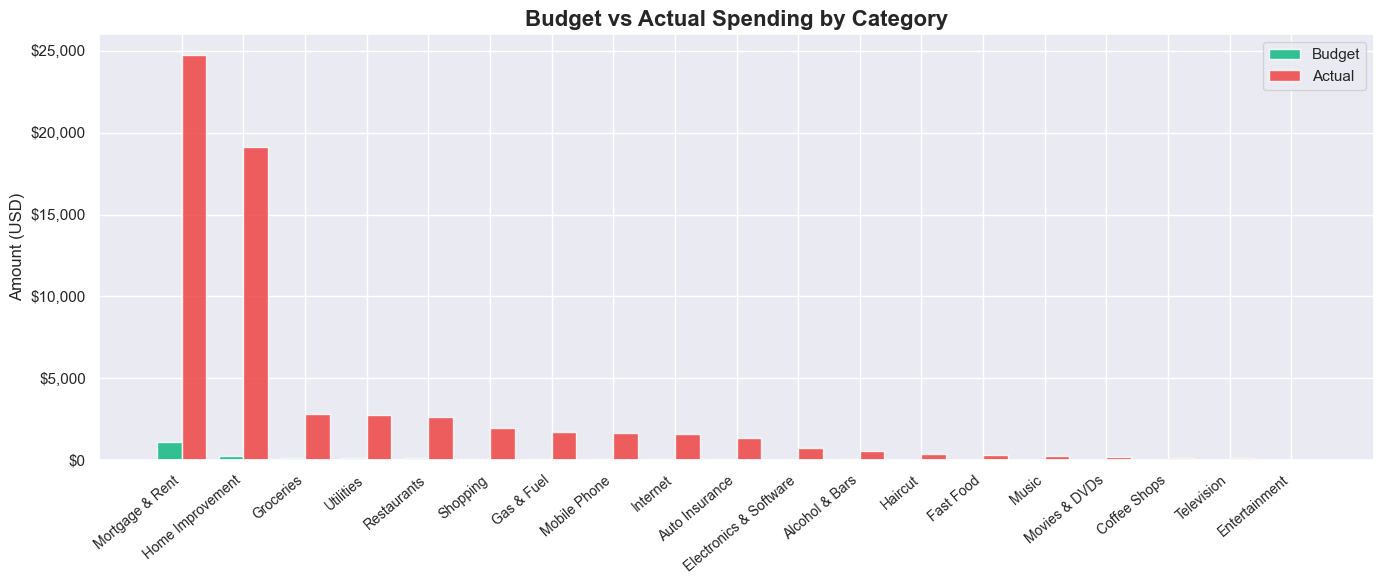

Categories over budget: 18/19
              Category  Budget   Actual
       Mortgage & Rent    1100 24754.50
      Home Improvement     250 19092.87
             Groceries     150  2795.21
             Utilities     150  2776.00
           Restaurants     150  2613.02
              Shopping     100  1973.24
            Gas & Fuel      75  1715.17
          Mobile Phone      65  1680.40
              Internet      75  1570.88
        Auto Insurance      75  1350.00
Electronics & Software       0   719.00
        Alcohol & Bars      50   539.13
               Haircut      30   378.00
             Fast Food      15   330.63
                 Music      11   224.49
         Movies & DVDs       0   222.19
          Coffee Shops      15   115.54
            Television      15   104.78


In [8]:
actual = (
    df[df['Transaction Type'] == 'debit']
    .groupby('Category')['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'Actual'})
)

comparison = bud.merge(actual, on='Category', how='inner')
comparison['Over Budget'] = comparison['Actual'] > comparison['Budget']
comparison = comparison.sort_values('Actual', ascending=False)

x = range(len(comparison))
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - 0.2 for i in x], comparison['Budget'], width=0.4, label='Budget', color='#10b981', alpha=0.85)
ax.bar([i + 0.2 for i in x], comparison['Actual'], width=0.4, label='Actual',
       color=['#ef4444' if o else '#3b82f6' for o in comparison['Over Budget']], alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(comparison['Category'], rotation=40, ha='right', fontsize=10)
ax.set_title('Budget vs Actual Spending by Category', fontsize=16, fontweight='bold')
ax.set_ylabel('Amount (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/budget_vs_actual.png', dpi=150)
plt.show()

over = comparison[comparison['Over Budget']]
print(f'Categories over budget: {len(over)}/{len(comparison)}')
print(over[['Category','Budget','Actual']].to_string(index=False))

## 9. Spending by Account

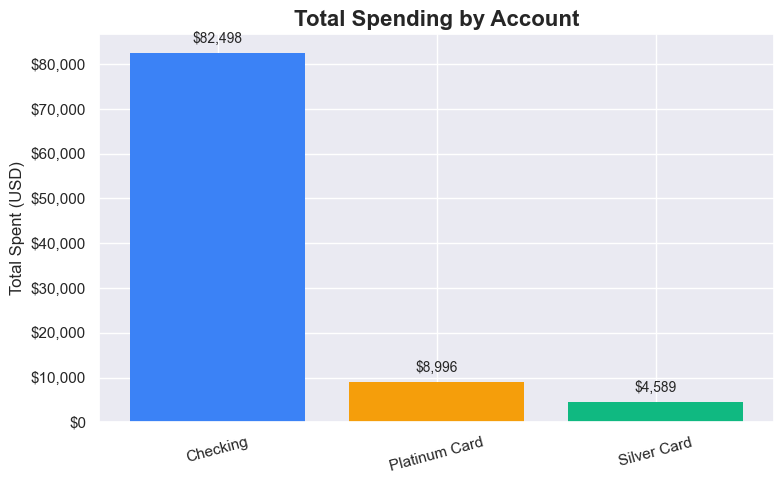

In [9]:
by_account = (
    df[df['Transaction Type'] == 'debit']
    .groupby('Account Name')['Amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

colors = ['#3b82f6', '#f59e0b', '#10b981', '#ef4444']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(by_account['Account Name'], by_account['Amount'],
              color=colors[:len(by_account)], edgecolor='none')
ax.bar_label(bars, fmt='${:,.0f}', padding=5, fontsize=10)
ax.set_title('Total Spending by Account', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Spent (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{OUT}/spending_by_account.png', dpi=150)
plt.show()

## 10. Key Statistics

In [10]:
debit = df[df['Transaction Type'] == 'debit']
avg_monthly = debit.groupby('Month')['Amount'].sum().mean()
top_category = debit.groupby('Category')['Amount'].sum().idxmax()
biggest_tx = debit.nlargest(1, 'Amount')[['Date','Description','Category','Amount']]

print('=' * 50)
print('         SPENDWISE - KEY STATISTICS')
print('=' * 50)
print(f'  Avg Monthly Spending : ${avg_monthly:>10,.2f}')
print(f'  Top Category         : {top_category}')
print(f'  Total Transactions   : {len(df):>10,}')
print(f'  Savings Rate         : {savings/income*100:>9.1f}%')
print('=' * 50)
print('\nBiggest Single Transaction:')
print(biggest_tx.to_string(index=False))

         SPENDWISE - KEY STATISTICS
  Avg Monthly Spending : $  4,575.42
  Top Category         : Credit Card Payment
  Total Transactions   :        806
  Savings Rate         :      22.7%

Biggest Single Transaction:
      Date             Description         Category  Amount
2019-06-20 Mike's Construction Co. Home Improvement  9200.0


---
**Tools:** Python - Pandas - NumPy - Matplotlib - Seaborn  
**Author:** Berke Arda Turk